Directory 'outputs/' ensured to exist.


/tmp/ipykernel_587/1327693950.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='short_title', data=top_10_stories, palette='viridis', ax=ax1)


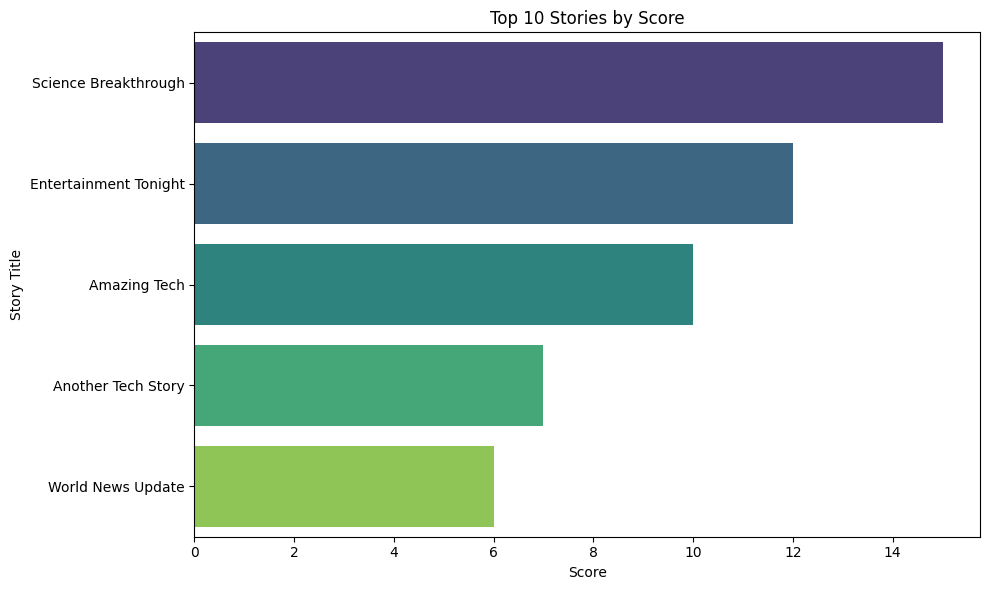

/tmp/ipykernel_587/1327693950.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='count', data=category_counts, palette='Paired', ax=ax2)


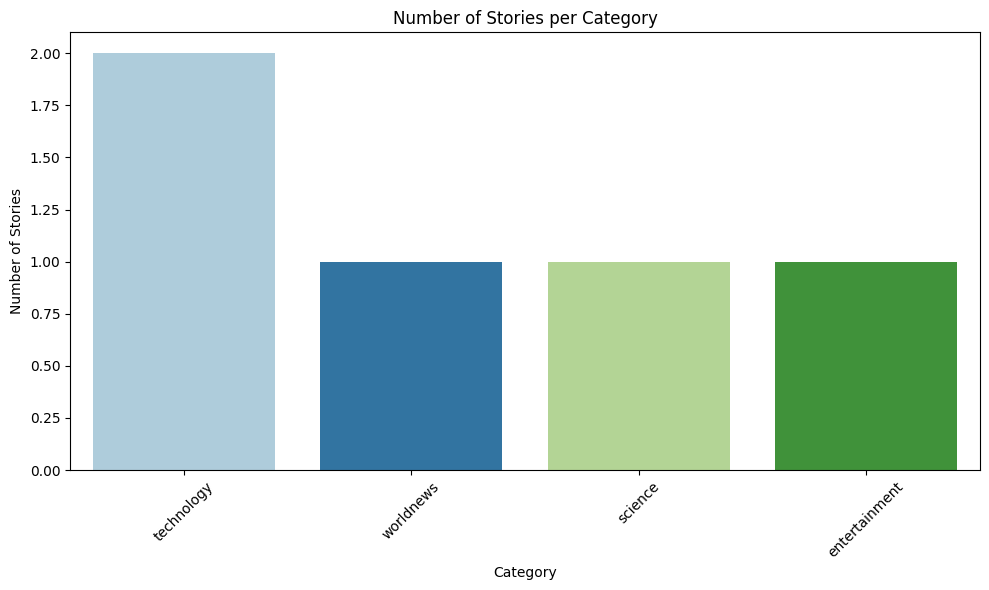

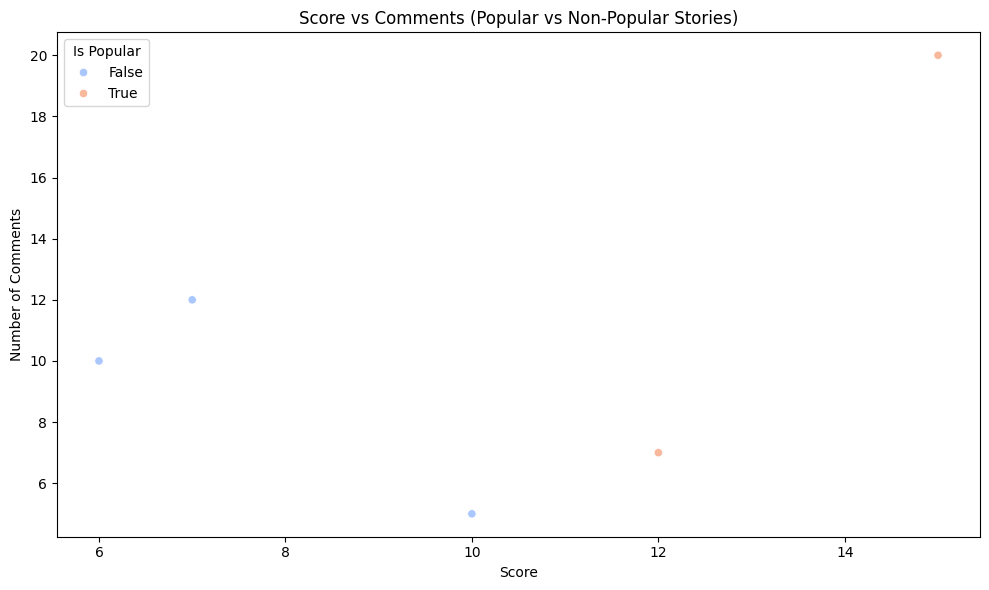

/tmp/ipykernel_587/1327693950.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='short_title', data=top_10_stories, palette='viridis', ax=axes[0])
/tmp/ipykernel_587/1327693950.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='count', data=category_counts, palette='Paired', ax=axes[1])


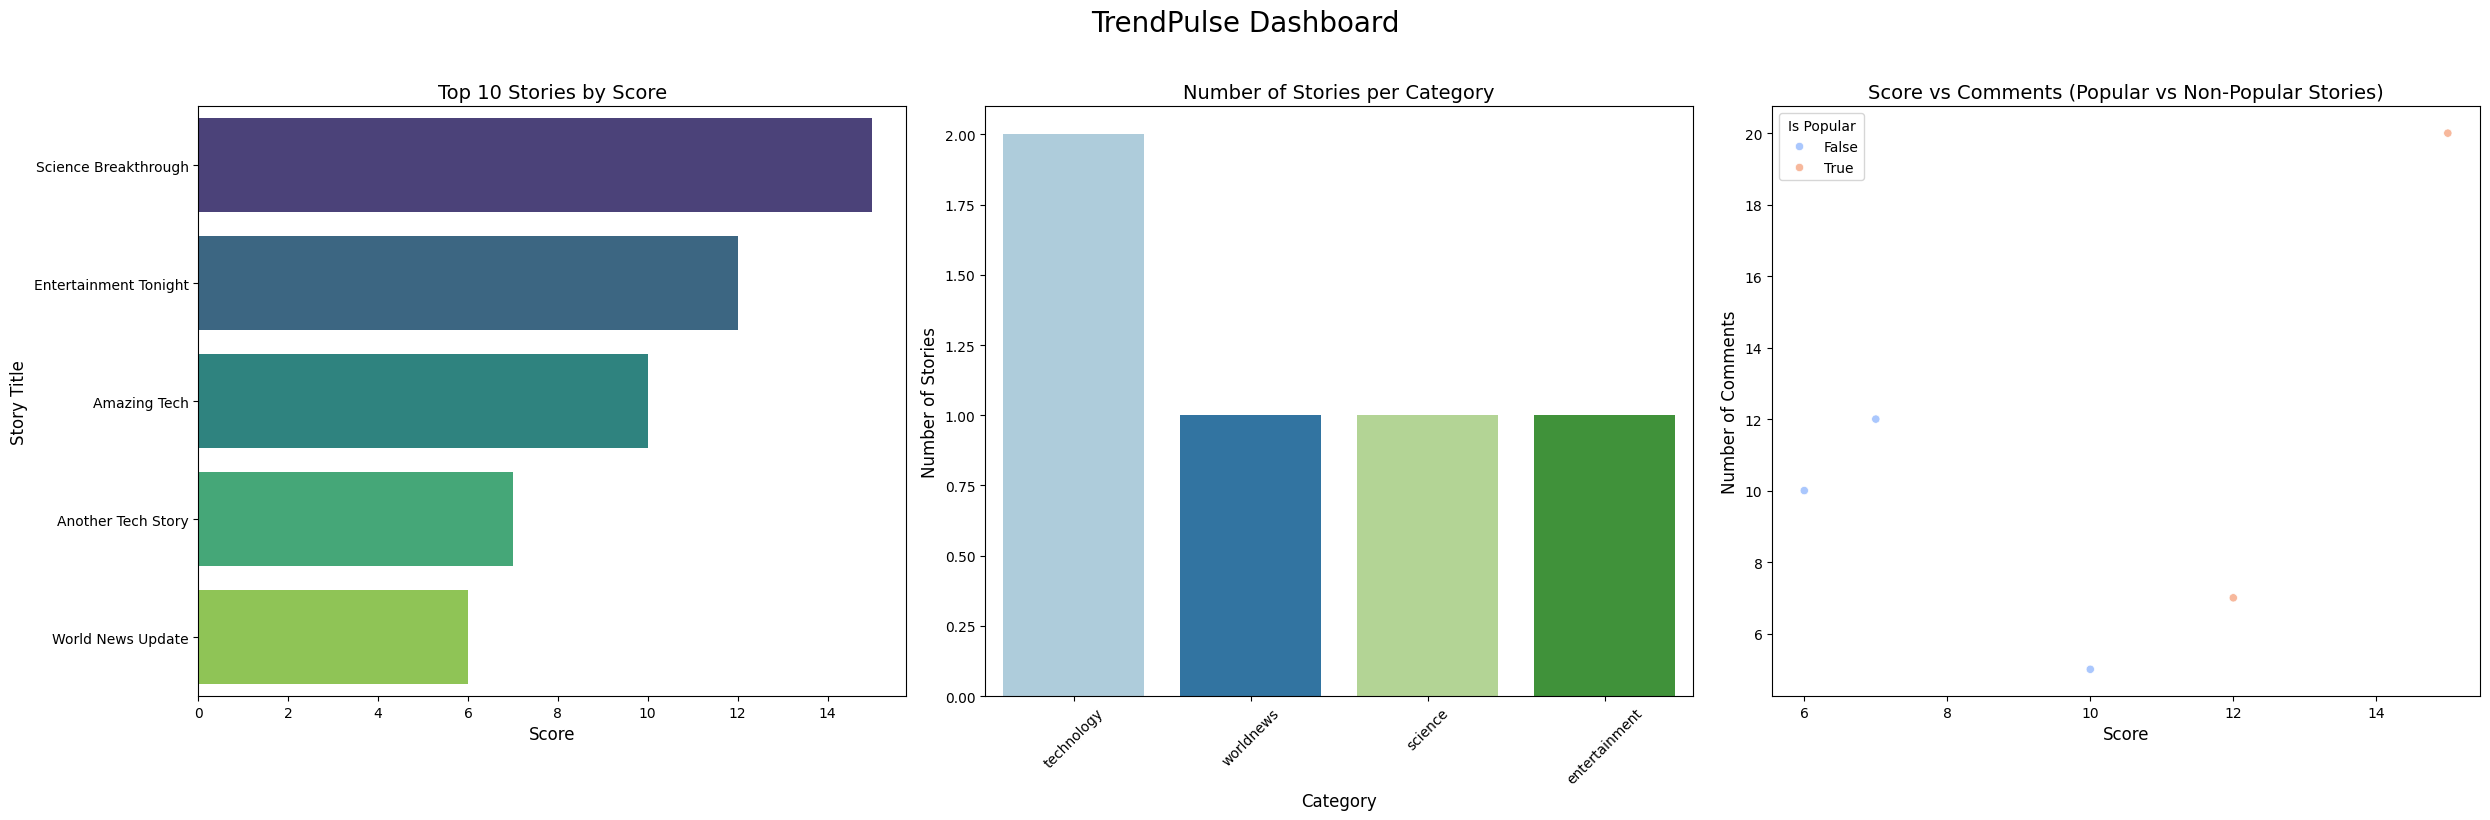

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

# --- Setup: Load data and create output directory ---
# Load data/trends_analysed.csv into a DataFrame
df = pd.read_csv('/content/trends_analysed.csv')

# Create a folder called outputs/ if it doesn't exist
output_dir = 'outputs/'
os.makedirs(output_dir, exist_ok=True)
print(f"Directory '{output_dir}' ensured to exist.")

# --- Chart 1: Top 10 Stories by Score ---
# Sort by score and get the top 10 stories
top_10_stories = df.nlargest(10, 'score')

# Shorten titles longer than 50 characters
top_10_stories['short_title'] = top_10_stories['title'].apply(lambda x: x[:50] + '...' if len(x) > 50 else x)

# Create the horizontal bar chart
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(x='score', y='short_title', data=top_10_stories, palette='viridis', ax=ax1)

# Add title and labels
ax1.set_title('Top 10 Stories by Score')
ax1.set_xlabel('Score')
ax1.set_ylabel('Story Title')

# Save the chart before showing
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'chart1_top_stories.png'))
plt.show()

# --- Chart 2: Stories per Category ---
# Calculate the number of stories per category
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

# Create the bar chart
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.barplot(x='category', y='count', data=category_counts, palette='Paired', ax=ax2)

# Add title and axis labels
ax2.set_title('Number of Stories per Category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Number of Stories')

# Rotate x-axis labels if they are too long
plt.xticks(rotation=45)

# Save the chart before showing
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'chart2_categories.png'))
plt.show()

# --- Chart 3: Score vs Comments ---
# Create a scatter plot with score on the x-axis and num_comments on the y-axis
fig3, ax3 = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='score', y='num_comments', hue='is_popular', data=df, palette='coolwarm', ax=ax3)

# Add a legend, title, and axis labels
ax3.set_title('Score vs Comments (Popular vs Non-Popular Stories)')
ax3.set_xlabel('Score')
ax3.set_ylabel('Number of Comments')
ax3.legend(title='Is Popular')

# Save the chart before showing
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'chart3_scatter.png'))
plt.show()

# --- Bonus — Dashboard ---
# Combine all 3 charts into one figure
fig, axes = plt.subplots(1, 3, figsize=(25, 8))
fig.suptitle('TrendPulse Dashboard', fontsize=20, y=1.02)

# Chart 1: Top 10 Stories by Score (using already calculated top_10_stories)
sns.barplot(x='score', y='short_title', data=top_10_stories, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Stories by Score', fontsize=14)
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_ylabel('Story Title', fontsize=12)

# Chart 2: Stories per Category (using already calculated category_counts)
sns.barplot(x='category', y='count', data=category_counts, palette='Paired', ax=axes[1])
axes[1].set_title('Number of Stories per Category', fontsize=14)
axes[1].set_xlabel('Category', fontsize=12)
axes[1].set_ylabel('Number of Stories', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Score vs Comments (using original df)
sns.scatterplot(x='score', y='num_comments', hue='is_popular', data=df, palette='coolwarm', ax=axes[2])
axes[2].set_title('Score vs Comments (Popular vs Non-Popular Stories)', fontsize=14)
axes[2].set_xlabel('Score', fontsize=12)
axes[2].set_ylabel('Number of Comments', fontsize=12)
axes[2].legend(title='Is Popular')

# Adjust layout and save the dashboard
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dashboard.png'))
plt.show()